
# Student Performance Analysis & Prediction

## 1. Dataset Loading and Initial Inspection

This project analyzes student academic and behavioral data and develops machine learning models to predict final examination scores.

The initial stage focuses on loading the dataset, inspecting its structure, identifying missing values, and checking data quality.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv("student_performance_dataset.csv")

print(df.head())
print(df.shape)
print(df.info())

   student_id  gender  study_time_hours  attendance_percent  sleep_hours  \
0           1    Male               4.0                98.0          6.5   
1           2  Female               6.3               100.0          5.7   
2           3    Male               4.9                85.3          7.9   
3           4    Male               2.6                77.5          8.0   
4           5    Male               2.2                89.6          4.6   

  parental_education internet_access extracurricular_activities part_time_job  \
0          Bachelors             Yes                        Yes            No   
1        High School             Yes                        Yes           Yes   
2          Bachelors             Yes                         No           Yes   
3                NaN             Yes                        Yes            No   
4          Bachelors             Yes                         No           Yes   

   previous_grade  final_exam_score final_grade  
0     

## 2. Data Quality Assessment

This stage evaluates the quality of the dataset by checking for missing values, duplicate records, and basic statistical properties.

In [ ]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
student_id                      0
gender                          0
study_time_hours                0
attendance_percent              0
sleep_hours                     0
parental_education            102
internet_access                 0
extracurricular_activities      0
part_time_job                   0
previous_grade                  0
final_exam_score                0
final_grade                     0
dtype: int64


In [ ]:
print(df.describe())

        student_id  study_time_hours  attendance_percent  sleep_hours  \
count  1000.000000       1000.000000         1000.000000  1000.000000   
mean    500.500000          3.570700           85.092300     6.799500   
std     288.819436          1.478559            9.270685     1.203527   
min       1.000000          0.500000           54.800000     3.200000   
25%     250.750000          2.600000           78.800000     5.900000   
50%     500.500000          3.600000           85.200000     6.800000   
75%     750.250000          4.500000           91.900000     7.600000   
max    1000.000000          8.100000          100.000000    10.000000   

       previous_grade  final_exam_score  
count     1000.000000       1000.000000  
mean        69.740900         83.543500  
std         12.613425         10.341333  
min         31.300000         46.800000  
25%         61.000000         76.075000  
50%         69.600000         83.800000  
75%         78.400000         91.525000  
max   

In [ ]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


## 3. Exploratory Data Analysis

In [ ]:
print("Parental Education Distribution:")
print(df["parental_education"].value_counts(dropna=False))

Parental Education Distribution:
parental_education
High School    356
Bachelors      308
Masters        184
NaN            102
PhD             50
Name: count, dtype: int64


In [ ]:
extracurricular_summary = (
    df.groupby("extracurricular_activities")["final_exam_score"]
    .agg(["count", "mean", "median"])
    .round(2)
)

extracurricular_summary

,count,mean,median
extracurricular_activities,,,
No,428,83.28,83.6
Yes,572,83.74,83.8


In [ ]:
categorical_columns = [
    "gender",
    "internet_access",
    "extracurricular_activities",
    "part_time_job"
]

for col in categorical_columns:
    print(f"\n{col}:")
    print(df[col].value_counts())


gender:
gender
Female    510
Male      490
Name: count, dtype: int64

internet_access:
internet_access
Yes    854
No     146
Name: count, dtype: int64

extracurricular_activities:
extracurricular_activities
Yes    572
No     428
Name: count, dtype: int64

part_time_job:
part_time_job
No     684
Yes    316
Name: count, dtype: int64


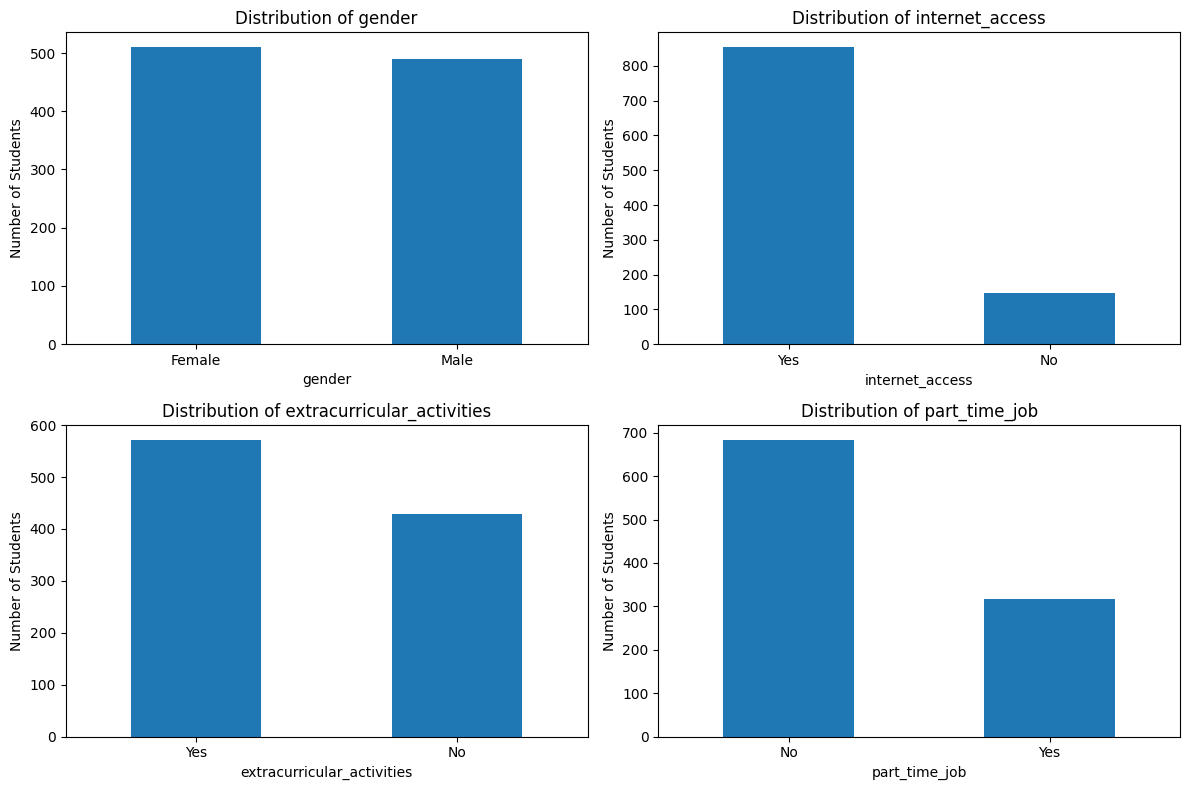

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, col in zip(axes.flatten(), categorical_columns):
    df[col].value_counts().plot(kind="bar", ax=ax)
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Number of Students")
    ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

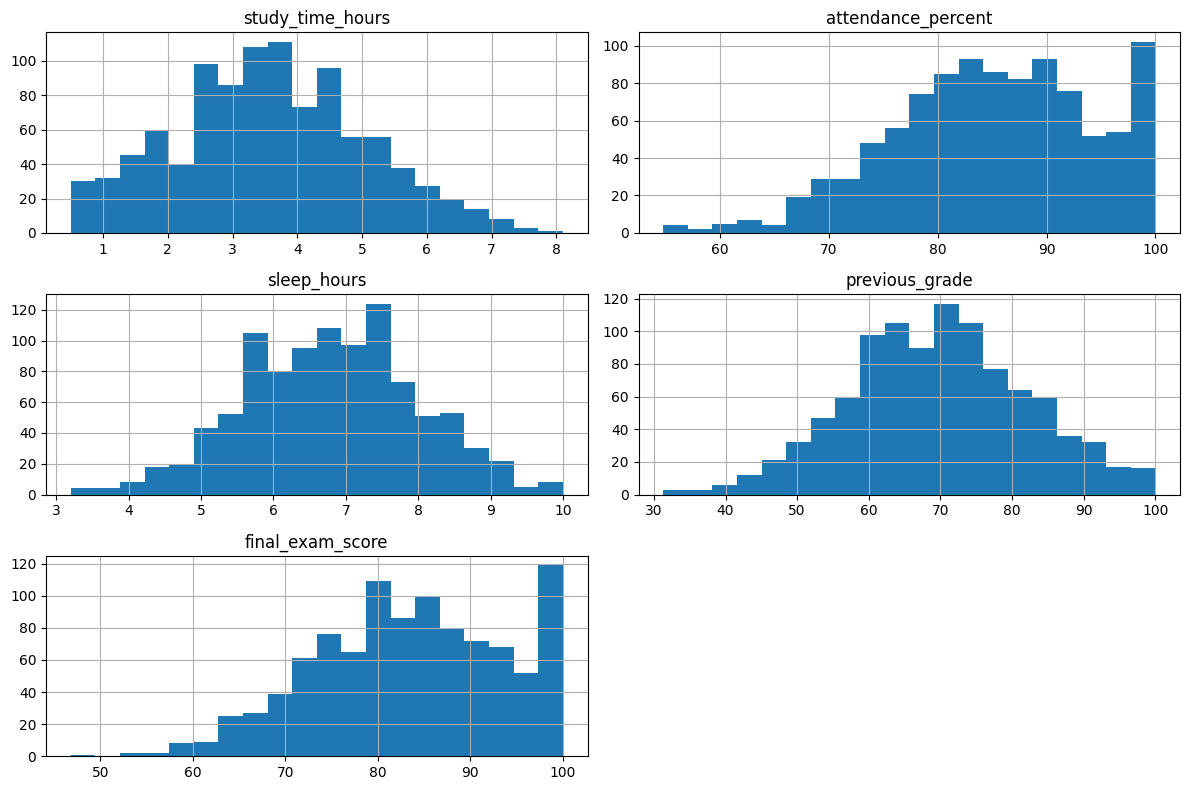

In [ ]:
numeric_columns = [
    "study_time_hours",
    "attendance_percent",
    "sleep_hours",
    "previous_grade",
    "final_exam_score"
]

df[numeric_columns].hist(figsize=(12, 8), bins=20)

plt.tight_layout()
plt.show()

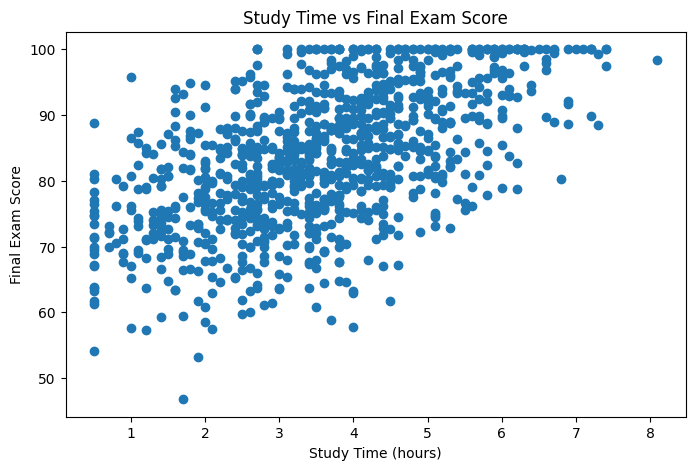

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["study_time_hours"],
    df["final_exam_score"]
)

plt.xlabel("Study Time (hours)")
plt.ylabel("Final Exam Score")
plt.title("Study Time vs Final Exam Score")

plt.show()

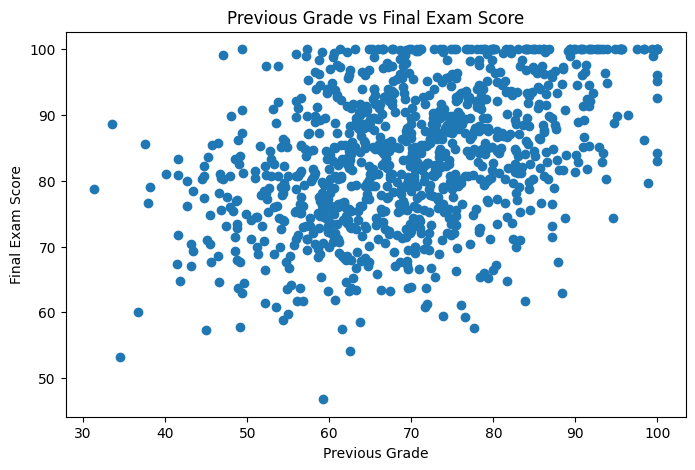

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(df["previous_grade"], df["final_exam_score"])

plt.xlabel("Previous Grade")
plt.ylabel("Final Exam Score")
plt.title("Previous Grade vs Final Exam Score")

plt.show()

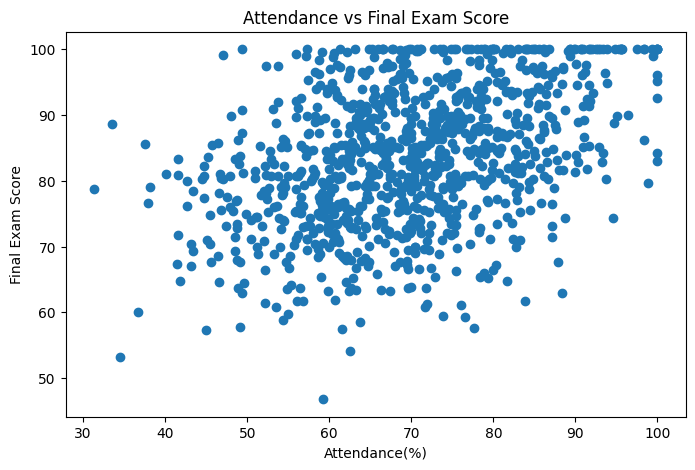

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(df["previous_grade"], df["final_exam_score"])

plt.xlabel("Attendance(%)")
plt.ylabel("Final Exam Score")
plt.title("Attendance vs Final Exam Score")

plt.show()

<Figure size 700x500 with 0 Axes>

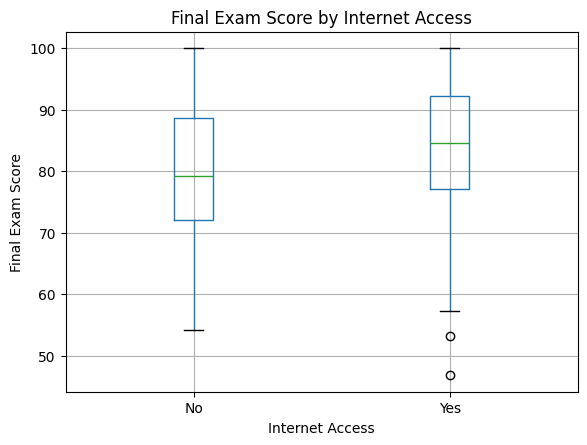

In [ ]:
plt.figure(figsize=(7, 5))

df.boxplot(
    column="final_exam_score",
    by="internet_access"
)

plt.xlabel("Internet Access")
plt.ylabel("Final Exam Score")
plt.title("Final Exam Score by Internet Access")

plt.suptitle("")

plt.show()

## Correlation Analysis

Correlation analysis is used to examine the linear relationship between the numerical variables in the dataset.

The selected variables include study time, attendance, sleep hours, previous grade, and final exam score.

A correlation heatmap is used to visualize the strength and direction of these relationships.

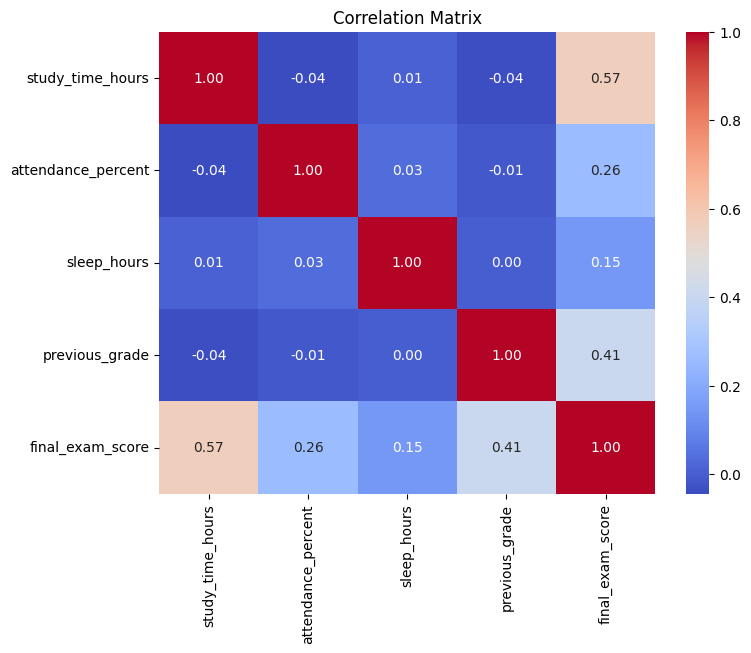

In [ ]:
numeric_cols = [
    "study_time_hours",
    "attendance_percent",
    "sleep_hours",
    "previous_grade",
    "final_exam_score"
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Matrix")
plt.show()

In [ ]:
low_scores = df[df["final_exam_score"] < 50]

print("Number of scores below 50:", len(low_scores))

if len(low_scores) > 0:
    display(low_scores)

Number of scores below 50: 1


,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
147,148,Male,1.7,83.5,5.7,Masters,Yes,Yes,Yes,59.2,46.8,F


In [ ]:
categorical_summary = {}

for col in ["gender", "internet_access", "part_time_job"]:
    categorical_summary[col] = (
        df.groupby(col)["final_exam_score"]
        .agg(["count", "mean", "median"])
        .round(2)
    )

for col, summary in categorical_summary.items():
    print(f"\n{col}")
    display(summary)


gender


,count,mean,median
gender,,,
Female,510,83.61,84.05
Male,490,83.48,83.20



internet_access


,count,mean,median
internet_access,,,
No,146,79.26,79.15
Yes,854,84.28,84.50



part_time_job


,count,mean,median
part_time_job,,,
No,684,84.58,84.6
Yes,316,81.29,82.0


In [ ]:
parental_summary = (
    df.groupby("parental_education", dropna=False)["final_exam_score"]
    .agg(["count", "mean", "median"])
    .round(2)
)

parental_summary

,count,mean,median
parental_education,,,
Bachelors,308,83.40,83.85
High School,356,83.23,83.15
Masters,184,84.03,84.95
PhD,50,85.06,83.65
NaN,102,83.44,82.30


EDA Findings

The exploratory analysis indicates that study time has the strongest observed relationship with final examination score among the numerical variables examined. Previous grade also shows a moderate positive relationship, while attendance has a weaker positive relationship. Sleep hours show a relatively weak relationship with final examination performance. Categorical analysis also indicates differences in examination scores across factors such as internet access and part-time employment.

## 4. Data Preprocessing

This stage prepares the dataset for machine learning by separating the target variable, encoding categorical variables, and creating training and testing datasets.

In [ ]:
print(df["parental_education"].isnull().sum())
print(df["parental_education"].value_counts(dropna=False))

102
parental_education
High School    356
Bachelors      308
Masters        184
NaN            102
PhD             50
Name: count, dtype: int64


### Handling Missing Values

The `parental_education` column contains missing values. These missing entries are replaced with the category `Unknown` so that the information is retained without removing student records.

In [ ]:
df["parental_education"] = df["parental_education"].fillna("Unknown")

### Verification of Missing Value Treatment

The distribution of the `parental_education` variable is checked after replacing missing values with `Unknown`.

In [ ]:
print(df["parental_education"].value_counts())

parental_education
High School    356
Bachelors      308
Masters        184
Unknown        102
PhD             50
Name: count, dtype: int64


### Descriptive Statistics

Descriptive statistics are calculated for the dataset to examine the central tendency and spread of the numerical variables.

In [ ]:
print(df.describe())

        student_id  study_time_hours  attendance_percent  sleep_hours  \
count  1000.000000       1000.000000         1000.000000  1000.000000   
mean    500.500000          3.570700           85.092300     6.799500   
std     288.819436          1.478559            9.270685     1.203527   
min       1.000000          0.500000           54.800000     3.200000   
25%     250.750000          2.600000           78.800000     5.900000   
50%     500.500000          3.600000           85.200000     6.800000   
75%     750.250000          4.500000           91.900000     7.600000   
max    1000.000000          8.100000          100.000000    10.000000   

       previous_grade  final_exam_score  
count     1000.000000       1000.000000  
mean        69.740900         83.543500  
std         12.613425         10.341333  
min         31.300000         46.800000  
25%         61.000000         76.075000  
50%         69.600000         83.800000  
75%         78.400000         91.525000  
max   

### Minimum Value Validation

The minimum values of the numerical variables are examined to verify that they fall within reasonable ranges.

In [ ]:
print(df[["study_time_hours", "attendance_percent", "sleep_hours",
          "previous_grade", "final_exam_score"]].min())

study_time_hours       0.5
attendance_percent    54.8
sleep_hours            3.2
previous_grade        31.3
final_exam_score      46.8
dtype: float64


### Maximum Value Validation

The maximum values of the numerical variables are examined to verify that they fall within reasonable ranges.

In [ ]:
print(df[["study_time_hours", "attendance_percent", "sleep_hours",
          "previous_grade", "final_exam_score"]].max())

study_time_hours        8.1
attendance_percent    100.0
sleep_hours            10.0
previous_grade        100.0
final_exam_score      100.0
dtype: float64


### Identification of Categorical Variables

The dataset is examined to identify categorical variables stored as object data types. These variables will be handled appropriately during the preprocessing stage before model training.

In [ ]:
print(df.select_dtypes(include="object").columns)

Index(['gender', 'parental_education', 'internet_access',
       'extracurricular_activities', 'part_time_job', 'final_grade'],
      dtype='object')


### Categorical Variable Distributions

The unique value counts of the categorical variables are examined to understand their distributions and verify the consistency of categorical data.

In [ ]:
for col in df.select_dtypes(include="object").columns:
    print("\n", col)
    print(df[col].value_counts())


 gender
gender
Female    510
Male      490
Name: count, dtype: int64

 parental_education
parental_education
High School    356
Bachelors      308
Masters        184
Unknown        102
PhD             50
Name: count, dtype: int64

 internet_access
internet_access
Yes    854
No     146
Name: count, dtype: int64

 extracurricular_activities
extracurricular_activities
Yes    572
No     428
Name: count, dtype: int64

 part_time_job
part_time_job
No     684
Yes    316
Name: count, dtype: int64

 final_grade
final_grade
B    354
A    284
C    261
D     89
F     12
Name: count, dtype: int64


## 4. Data Preprocessing

### Feature and Target Selection

The dataset is separated into input features and the target variable. The `final_exam_score` is selected as the target because the objective of the project is to predict students' final examination scores.

In [ ]:
X = df.drop(columns=[
    "student_id",
    "final_exam_score",
    "final_grade"
])

y = df["final_exam_score"]

print("Features:")
print(X.columns)

print("\nTarget:")
print(y.name)

Features:
Index(['gender', 'study_time_hours', 'attendance_percent', 'sleep_hours',
       'parental_education', 'internet_access', 'extracurricular_activities',
       'part_time_job', 'previous_grade'],
      dtype='object')

Target:
final_exam_score


### Categorical Variable Encoding

Categorical variables are converted into numerical representations using one-hot encoding so that they can be used by the machine learning models.

Each category is represented as a binary feature. The `drop_first=True` option removes one category from each categorical variable to avoid redundant features.

In [ ]:
from sklearn.preprocessing import OneHotEncoder

categorical_columns = [
    "gender",
    "internet_access",
    "extracurricular_activities",
    "part_time_job",
    "parental_education"
]

encoder = OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False)

encoded_data = encoder.fit_transform(df[categorical_columns])

encoded_columns = encoder.get_feature_names_out(categorical_columns)

encoded_df = pd.DataFrame(
    encoded_data,
    columns=encoded_columns,
    index=df.index
)

X_numeric = df.drop(
    columns=categorical_columns + [
        "student_id",
        "final_exam_score",
        "final_grade"
    ]
)

X = pd.concat([X_numeric, encoded_df], axis=1)

y = df["final_exam_score"]

print("Features:")
print(X.columns)

print("\nFeature matrix shape:")
print(X.shape)

Features:
Index(['study_time_hours', 'attendance_percent', 'sleep_hours',
       'previous_grade', 'gender_Male', 'internet_access_Yes',
       'extracurricular_activities_Yes', 'part_time_job_Yes',
       'parental_education_High School', 'parental_education_Masters',
       'parental_education_PhD', 'parental_education_Unknown'],
      dtype='object')

Feature matrix shape:
(1000, 12)


### Verification of Encoded Features

The feature matrix is checked to confirm that all input variables are numerical after encoding and that no categorical columns remain.

In [ ]:
print("Non-numerical columns:")
print(X.select_dtypes(exclude="number").columns)

print("\nData types:")
print(X.dtypes)

Non-numerical columns:
Index([], dtype='object')

Data types:
study_time_hours                  float64
attendance_percent                float64
sleep_hours                       float64
previous_grade                    float64
gender_Male                       float64
internet_access_Yes               float64
extracurricular_activities_Yes    float64
part_time_job_Yes                 float64
parental_education_High School    float64
parental_education_Masters        float64
parental_education_PhD            float64
parental_education_Unknown        float64
dtype: object


##  Train-Test Split

The dataset is divided into training and testing sets using an 80:20 split. The training set is used to build the machine learning models, while the test set is reserved for evaluating their performance on unseen data.

A fixed `random_state` is used to ensure that the same split can be reproduced.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (800, 12)
X_test: (200, 12)
y_train: (800,)
y_test: (200,)


### Verification of Feature Set

The feature columns and dimensions of the input dataset are checked after separating the features from the target variable.

In [ ]:
print(X.columns)
print(X.shape)

Index(['study_time_hours', 'attendance_percent', 'sleep_hours',
       'previous_grade', 'gender_Male', 'internet_access_Yes',
       'extracurricular_activities_Yes', 'part_time_job_Yes',
       'parental_education_High School', 'parental_education_Masters',
       'parental_education_PhD', 'parental_education_Unknown'],
      dtype='object')
(1000, 12)


## 4. Linear Regression Model

Linear Regression is used to predict the `final_exam_score` based on the selected input features.

The model is trained using the encoded training data (`X_train_encoded`, `y_train`) and then used to generate predictions on the test data (`X_test_encoded`).

The predicted values are evaluated using standard regression metrics such as **MAE, MSE, RMSE, and R² score**.

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train_encoded, y_train)

y_pred = model.predict(X_test_encoded)

print(y_pred[:10])

[78.09229498 73.51316754 73.61828627 91.05428211 88.56113498 69.99872146
 93.49708451 73.93563297 72.81721133 65.72626105]


### 4.1 Model Evaluation

The Linear Regression model is evaluated using four metrics:

- **MAE (Mean Absolute Error):** Measures the average absolute difference between actual and predicted values.
- **MSE (Mean Squared Error):** Measures the average squared difference between actual and predicted values.
- **RMSE (Root Mean Squared Error):** Represents the square root of MSE and is expressed in the same units as the target variable.
- **R² Score:** Indicates how much of the variation in the target variable is explained by the model.

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 4.979680899477105
MSE : 41.180276157351344
RMSE: 6.417185999903022
R²  : 0.6174150866192487


4.2 Linear Regression Coefficient Analysis
The coefficients of the Linear Regression model are examined to understand the relationship between each feature and the predicted final_exam_score.

A positive coefficient indicates that an increase in the corresponding feature is associated with an increase in the predicted score, while a negative coefficient indicates an inverse relationship.

The coefficients are sorted in descending order to identify the features with relatively larger positive and negative effects on the model's predictions.

In [ ]:
feature_names = preprocessor.get_feature_names_out()

coefficients = model.coef_

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

coef_df = coef_df.sort_values(
    by="coefficient",
    ascending=False
)

print(coef_df)

                                feature  coefficient
13                num__study_time_hours     4.119319
8              cat__internet_access_Yes     2.998419
11                cat__part_time_job_No     1.793806
15                     num__sleep_hours     1.011103
5           cat__parental_education_PhD     0.738143
4       cat__parental_education_Masters     0.478955
10  cat__extracurricular_activities_Yes     0.418787
16                  num__previous_grade     0.351116
14              num__attendance_percent     0.334229
0                    cat__gender_Female     0.052482
3   cat__parental_education_High School    -0.015701
1                      cat__gender_Male    -0.052482
2     cat__parental_education_Bachelors    -0.329422
9    cat__extracurricular_activities_No    -0.418787
6       cat__parental_education_Unknown    -0.871975
12               cat__part_time_job_Yes    -1.793806
7               cat__internet_access_No    -2.998419


## 5. Random Forest Regression

Random Forest Regression is used as a second regression model to predict the `final_exam_score`.

The model combines multiple decision trees and averages their predictions to produce the final output. It is trained using the encoded training data (`X_train_encoded`, `y_train`) and evaluated on the encoded test data (`X_test_encoded`).

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train_encoded, y_train)

rf_pred = rf_model.predict(X_test_encoded)

print(rf_pred[57:67])

[70.535  73.3105 73.0925 70.9685 94.76   90.386  71.212  89.5415 92.5485
 96.3965]


### 5.1 Random Forest Model Evaluation

The Random Forest model is evaluated using the same regression metrics used for Linear Regression:

- **MAE (Mean Absolute Error):** Measures the average absolute prediction error.
- **MSE (Mean Squared Error):** Measures the average squared prediction error.
- **RMSE (Root Mean Squared Error):** Measures prediction error in the same units as the target variable.
- **R² Score:** Measures the proportion of variation in `final_exam_score` explained by the model.

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest")
print("MAE :", rf_mae)
print("MSE :", rf_mse)
print("RMSE:", rf_rmse)
print("R²  :", rf_r2)

Random Forest
MAE : 5.230667499999993
MSE : 46.08938871124994
RMSE: 6.788916608064201
R²  : 0.5718070291590907


**Residual** **Analysis**

Residuals represent the difference between the actual and predicted final exam scores.

The residual plot is used to examine the distribution of prediction errors and identify any systematic patterns in the model's predictions.

In [ ]:
residuals = y_test - rf_pred

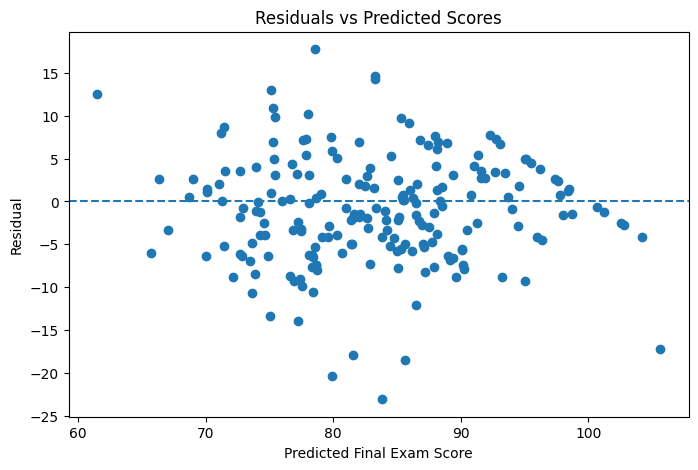

In [ ]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 5))

plt.scatter(y_pred, residuals)

plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted Final Exam Score")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted Scores")

plt.show()

### 5.2 Random Forest Residual Analysis

Residual analysis is performed to examine the prediction errors of the Random Forest Regression model.

The residual is calculated as the difference between the actual `final_exam_score` and the predicted score.

A residual plot is used to visualize the distribution of prediction errors across the predicted values. Ideally, residuals should be distributed around zero without a clear systematic pattern.

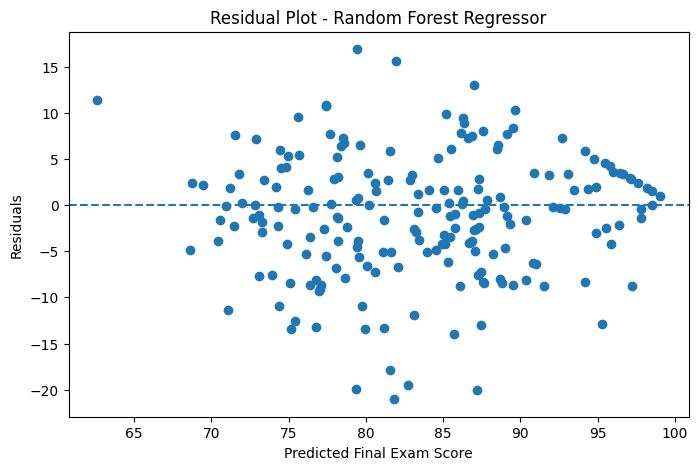

In [ ]:
residuals = y_test - rf_pred

plt.figure(figsize=(8, 5))
plt.scatter(rf_pred, residuals)
plt.axhline(y=0, linestyle="--")
plt.xlabel("Predicted Final Exam Score")
plt.ylabel("Residuals")
plt.title("Residual Plot - Random Forest Regressor")
plt.show()

## Actual vs Predicted Values

The actual vs predicted plot compares the model's predicted final exam scores with the actual scores from the test dataset.

The dashed diagonal line represents perfect predictions, where the predicted score is equal to the actual score.

Points closer to the diagonal line indicate smaller prediction errors.

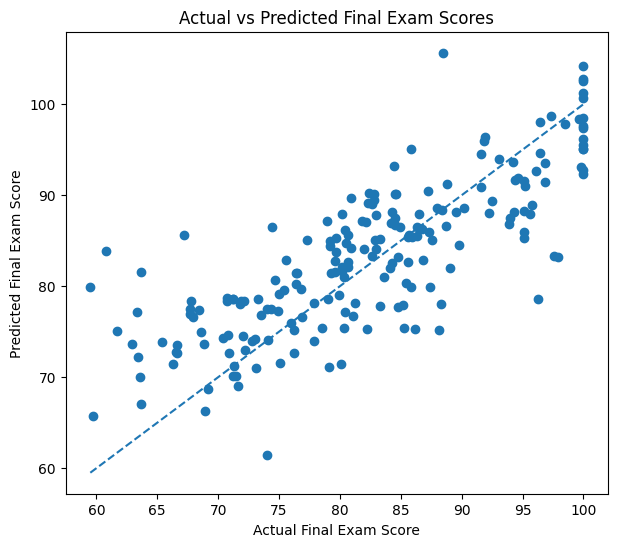

In [ ]:
plt.figure(figsize=(7, 6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Final Exam Score")
plt.ylabel("Predicted Final Exam Score")
plt.title("Actual vs Predicted Final Exam Scores")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.show()

## Model Comparison

The Linear Regression and Random Forest models are compared using MAE, MSE, RMSE, and R² score to evaluate their prediction performance on the test dataset.

In [ ]:
Acomparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae, rf_mae],
    "MSE": [mse, rf_mse],
    "RMSE": [rmse, rf_rmse],
    "R²": [r2, rf_r2]
})

print(comparison)

               Model       MAE        MSE      RMSE        R²
0  Linear Regression  4.979681  41.180276  6.417186  0.617415
1      Random Forest  5.230667  46.089389  6.788917  0.571807


## Feature Importance

Feature importance from the Random Forest model is used to identify which features contribute most to predicting the final exam score.

The features are ranked according to their importance values, with higher values indicating greater contribution to the model's predictions.

In [ ]:
feature_names = preprocessor.get_feature_names_out()

importances = rf_model.feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(importance_df)

                                Feature  Importance
13                num__study_time_hours    0.389839
16                  num__previous_grade    0.266952
14              num__attendance_percent    0.157815
15                     num__sleep_hours    0.070853
8              cat__internet_access_Yes    0.015977
7               cat__internet_access_No    0.015634
11                cat__part_time_job_No    0.012998
12               cat__part_time_job_Yes    0.012536
3   cat__parental_education_High School    0.008307
2     cat__parental_education_Bachelors    0.007872
4       cat__parental_education_Masters    0.006430
6       cat__parental_education_Unknown    0.006333
0                    cat__gender_Female    0.006081
1                      cat__gender_Male    0.006055
10  cat__extracurricular_activities_Yes    0.005835
9    cat__extracurricular_activities_No    0.005801
5           cat__parental_education_PhD    0.004680


## Random Forest Feature Importance

The feature importance values from the Random Forest model are visualized using a bar chart.

The chart shows the relative contribution of each feature to the model's predictions of the final exam score.

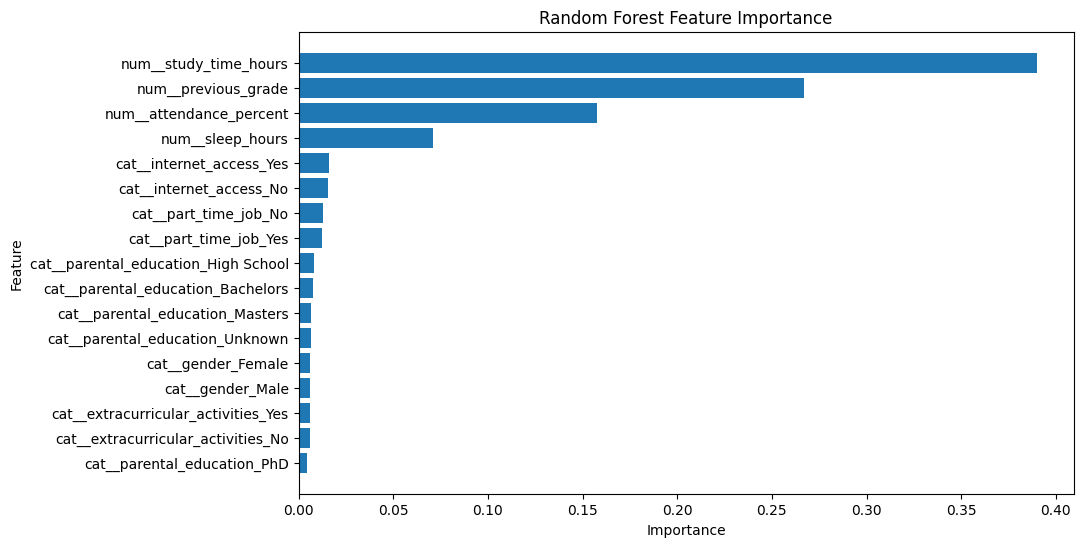

In [ ]:
plt.figure(figsize=(10, 6))

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()

plt.show()

# Final Findings and Conclusion

## Key Findings

- Study time hours showed the highest feature importance in the Random Forest model.
- Previous grade and attendance percentage were the next most influential numerical features.
- Sleep hours had a smaller contribution to the Random Forest predictions.
- Categorical variables such as internet access, part-time job, parental education, gender, and extracurricular activities had comparatively lower feature importance.
- The correlation analysis showed a positive relationship between study time and final exam score.
- The Linear Regression model achieved lower MAE, MSE, and RMSE than the Random Forest model on the test dataset.
- The Linear Regression model also achieved a higher R² score of approximately 0.617 compared with approximately 0.572 for Random Forest.

## Conclusion

This project analyzed student study habits and academic performance and developed machine learning models to predict final exam scores.

The analysis indicates that study time, previous grade, and attendance percentage were important variables for predicting final exam scores in the models used. Among the two evaluated models, Linear Regression produced smaller prediction errors and a higher R² score on the given test dataset.

The project demonstrates how exploratory data analysis, statistical relationships, feature analysis, and machine learning can be combined to understand and predict student academic performance.

The observed relationships and feature importance values describe patterns in the dataset and should not be interpreted as proof of causal relationships.

# Project Summary

**Dataset:** Student Performance and Study Habits

**Target Variable:** `final_exam_score`

**Models Used:**
- Linear Regression
- Random Forest Regressor

**Evaluation Metrics:**
- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score

**Based on the calculated test-set metrics, Linear Regression produced lower MAE, MSE, and RMSE, along with a higher R² score than Random Forest Regressor.**